In [1]:
# ==========================================
# FULL ENERGY ANALYTICS PIPELINE (Colab)
# ==========================================

# Step 0: Upload your files first
from google.colab import files
uploaded = files.upload()

# Step 1: Import Libraries
import pandas as pd
import numpy as np

# ----------------------------
# Step 2: Read CSV Files
# ----------------------------
energy_df = pd.read_csv("loureiro_energy.csv")
weather_df = pd.read_csv("weather_aveiro_final.csv")

# ----------------------------
# Step 3: Standardize Timestamps
# ----------------------------
# Energy
energy_df = energy_df.copy()
energy_df.rename(columns={'Time': 'timestamp'}, inplace=True)
energy_df['timestamp'] = pd.to_datetime(energy_df['timestamp'])

# Weather
weather_df = weather_df.copy()
weather_df.rename(columns={'Time': 'timestamp'}, inplace=True)
weather_df['timestamp'] = pd.to_datetime(weather_df['timestamp'])

# ----------------------------
# Step 4: Wide → Long Transform (Energy Meters)
# ----------------------------
energy_meter_cols = [col for col in energy_df.columns if col.startswith("Energy_Meter")]

energy_long = energy_df.melt(
    id_vars=['timestamp'],
    value_vars=energy_meter_cols,
    var_name='meter_id',
    value_name='energy_consumption'
)

# ----------------------------
# Step 5: Clean Energy Values
# ----------------------------
energy_long['energy_consumption'] = (
    energy_long['energy_consumption']
    .fillna(0)
    .clip(lower=0)
    .astype(float)
)

# ----------------------------
# Step 6: Aggregate Energy (Optional but Recommended)
# ----------------------------
energy_agg = energy_long.groupby('timestamp', as_index=False).agg(
    total_energy_kwh=('energy_consumption', 'sum')
)

# ----------------------------
# Step 7: Clean Weather Data
# ----------------------------
#weather_df = weather_df.set_index('timestamp').resample('15T').ffill().reset_index()
#weather_df = weather_df.set_index('timestamp').resample('15min').ffill().reset_index()
# After resampling
weather_df = weather_df.set_index('timestamp').resample('15min').ffill().bfill().reset_index()
# Step 8: Merge Energy & Weather
# ----------------------------
merged_df = pd.merge(energy_agg, weather_df, on='timestamp', how='left')
# Double-check nulls
print("Nulls per column after merge:")
print(merged_df.isnull().sum())

# Assert no nulls remain
assert merged_df.isnull().sum().sum() == 0, "Null values still exist!"
merged_df.to_csv("final_energy_weather.csv", index=False)
print("Final cleaned dataset saved as 'final_energy_weather.csv'")
files.download("final_energy_weather.csv")

Saving weather_aveiro_final.csv to weather_aveiro_final.csv
Saving loureiro_energy.csv to loureiro_energy.csv
Nulls per column after merge:
timestamp              0
total_energy_kwh       0
Avg_Temp               0
Avg_Rel_Humidity       0
Avg_Wind_Direction     0
Avg_Wind_Speed         0
Max_Inst_Wind_Speed    0
Inst_Temp              0
Quantity_Precip        0
Max_Inst_Precip        0
Total_Global_Rad       0
dtype: int64
Final cleaned dataset saved as 'final_energy_weather.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

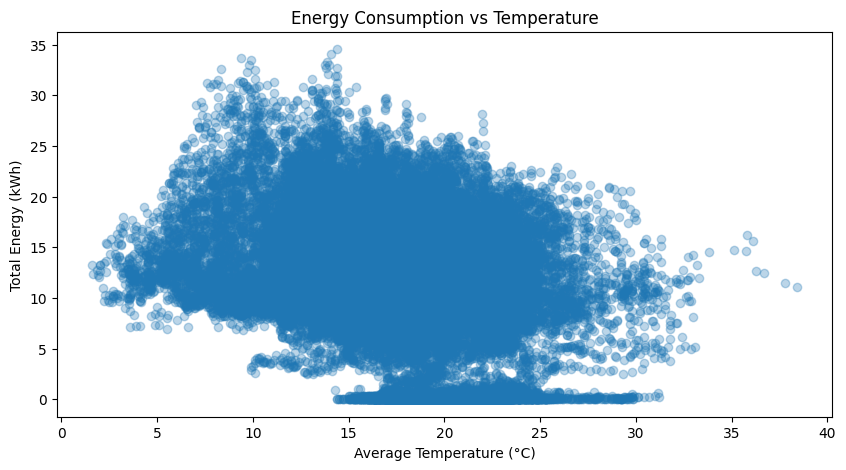

In [3]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(merged_df['Avg_Temp'], merged_df['total_energy_kwh'], alpha=0.3)
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Total Energy (kWh)')
plt.title('Energy Consumption vs Temperature')
plt.show()


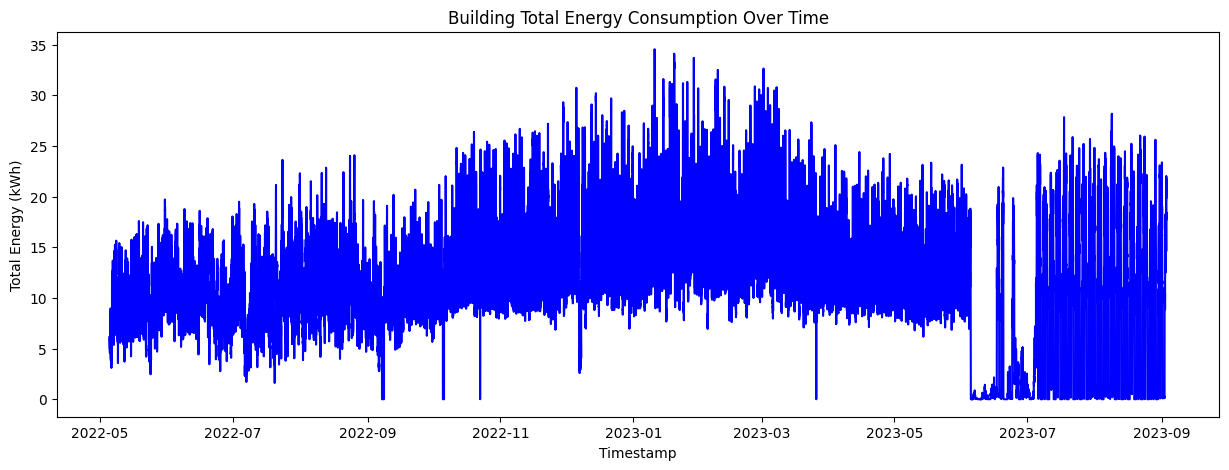

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(merged_df['timestamp'], merged_df['total_energy_kwh'], color='blue')
plt.xlabel('Timestamp')
plt.ylabel('Total Energy (kWh)')
plt.title('Building Total Energy Consumption Over Time')
plt.show()


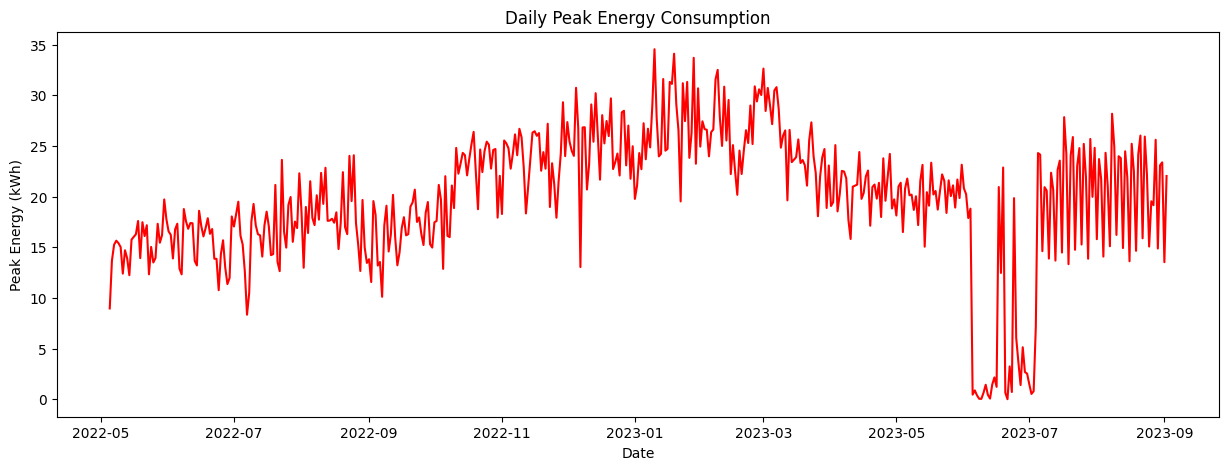

In [6]:
merged_df['date'] = merged_df['timestamp'].dt.date
daily_peak = merged_df.groupby('date')['total_energy_kwh'].max().reset_index()

plt.figure(figsize=(15,5))
plt.plot(daily_peak['date'], daily_peak['total_energy_kwh'], color='red')
plt.xlabel('Date')
plt.ylabel('Peak Energy (kWh)')
plt.title('Daily Peak Energy Consumption')
plt.show()
